In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

from scipy.stats import chi2_contingency, ttest_ind, f_oneway


df = pd.read_csv("german_credit_data.csv",index_col=0)



In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Age               1000 non-null   int64 
 1   Sex               1000 non-null   object
 2   Job               1000 non-null   int64 
 3   Housing           1000 non-null   object
 4   Saving accounts   817 non-null    object
 5   Checking account  606 non-null    object
 6   Credit amount     1000 non-null   int64 
 7   Duration          1000 non-null   int64 
 8   Purpose           1000 non-null   object
 9   Risk              1000 non-null   object
dtypes: int64(4), object(6)
memory usage: 85.9+ KB


In [3]:
df.head()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,49,male,1,own,little,NaN,2096,12,education,good
3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,53,male,2,free,little,little,4870,24,car,bad


In [4]:
df.describe()

,Age,Job,Credit amount,Duration
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,35.546000,1.904000,3271.258000,20.903000
std,11.375469,0.653614,2822.736876,12.058814
min,19.000000,0.000000,250.000000,4.000000
25%,27.000000,2.000000,1365.500000,12.000000
50%,33.000000,2.000000,2319.500000,18.000000
75%,42.000000,2.000000,3972.250000,24.000000
max,75.000000,3.000000,18424.000000,72.000000


In [5]:
df.isnull().sum()

Age                   0
Sex                   0
Job                   0
Housing               0
Saving accounts     183
Checking account    394
Credit amount         0
Duration              0
Purpose               0
Risk                  0
dtype: int64

In [6]:
df['Risk'].value_counts(normalize=True)

Risk
good    0.7
bad     0.3
Name: proportion, dtype: float64

In [7]:
pd.crosstab(df['Sex'], df['Risk'])

Risk,bad,good
Sex,,
female,109,201
male,191,499


<Axes: xlabel='Risk', ylabel='Credit amount'>

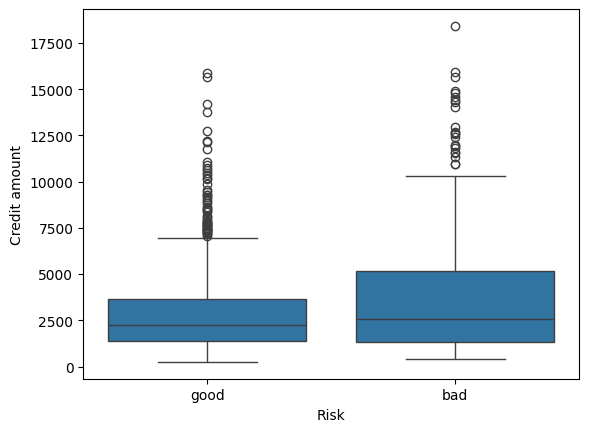

In [8]:
sns.boxplot(x='Risk', y='Credit amount', data=df)

In [9]:
df["Saving accounts"] = df["Saving accounts"].fillna("unknown")
df["Checking account"] = df["Checking account"].fillna("unknown")

In [10]:
df["Risk"] = df["Risk"].map({"good": 0, "bad": 1})

print(df["Risk"].value_counts())
print(df["Risk"].value_counts(normalize=True))

Risk
0    700
1    300
Name: count, dtype: int64
Risk
0    0.7
1    0.3
Name: proportion, dtype: float64


Risk
0    700
1    300
Name: count, dtype: int64


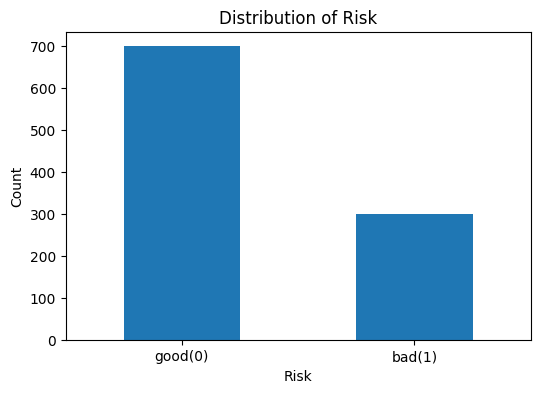

In [11]:
risk_counts = df["Risk"].value_counts().sort_index()
print(risk_counts)

plt.figure(figsize=(6,4))
risk_counts.plot(kind="bar")
plt.xticks([0,1], ["good(0)", "bad(1)"], rotation=0)
plt.title("Distribution of Risk")
plt.ylabel("Count")
plt.show()

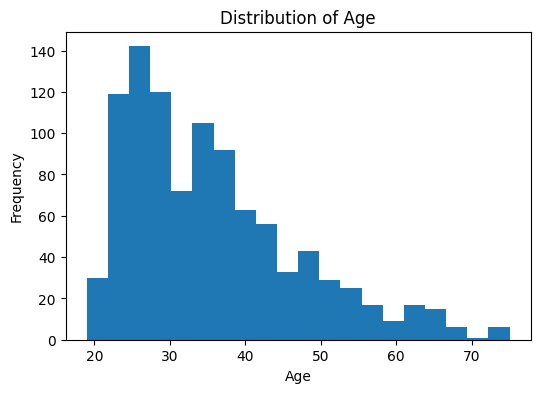

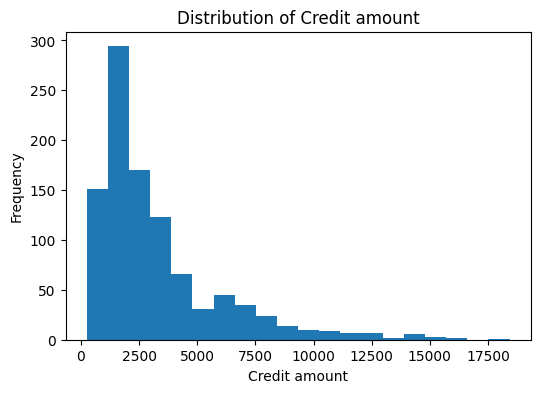

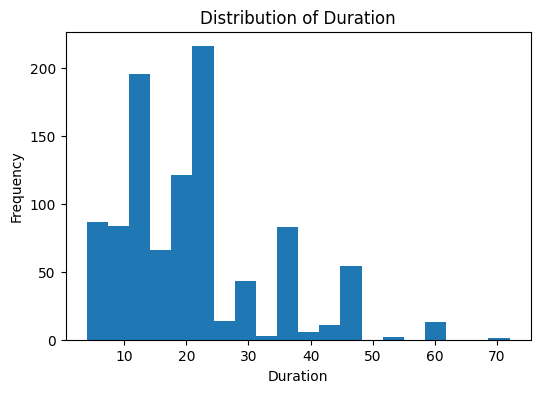

In [12]:
numeric_cols = ["Age", "Credit amount", "Duration"]

for col in numeric_cols:
    plt.figure(figsize=(6,4))
    plt.hist(df[col], bins=20)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

<Figure size 600x400 with 0 Axes>

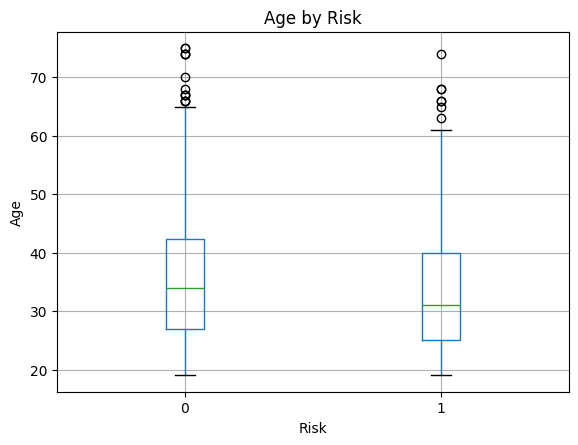

<Figure size 600x400 with 0 Axes>

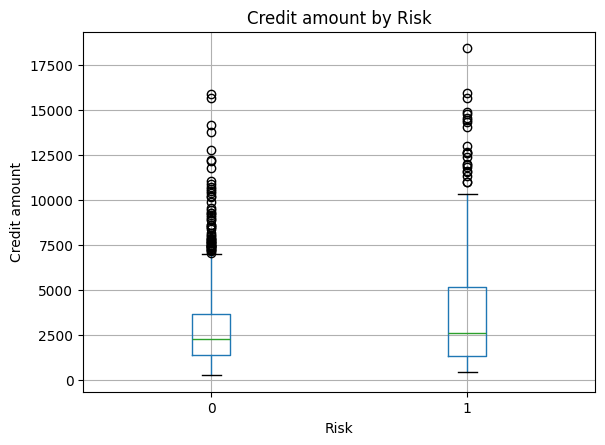

<Figure size 600x400 with 0 Axes>

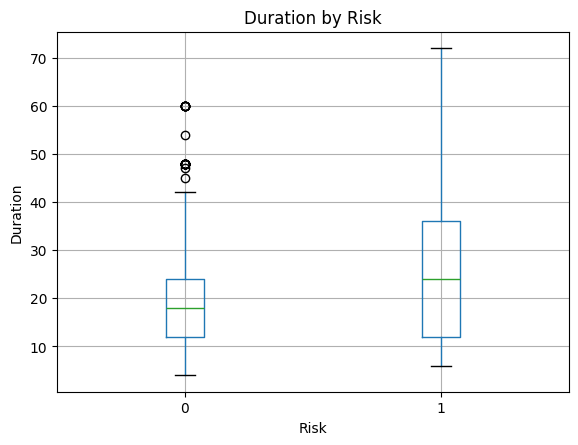

In [13]:
for col in numeric_cols:
    plt.figure(figsize=(6,4))
    df.boxplot(column=col, by="Risk")
    plt.title(f"{col} by Risk")
    plt.suptitle("")
    plt.xlabel("Risk")
    plt.ylabel(col)
    plt.show()


===== Sex vs Risk (row percentage) =====
Risk           0         1
Sex                       
female  0.648387  0.351613
male    0.723188  0.276812


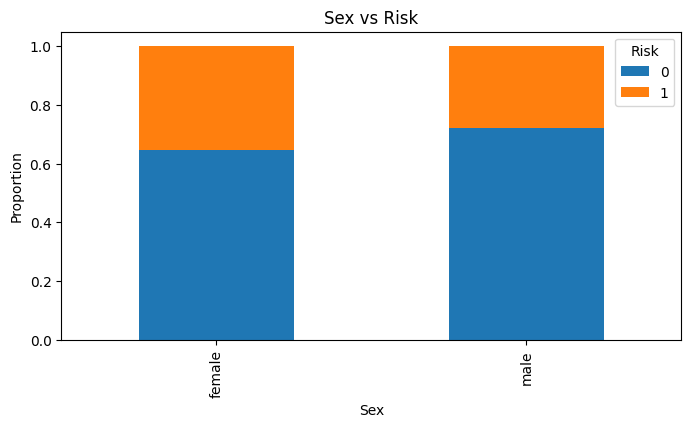


===== Job vs Risk (row percentage) =====
Risk         0         1
Job                     
0     0.681818  0.318182
1     0.720000  0.280000
2     0.704762  0.295238
3     0.655405  0.344595


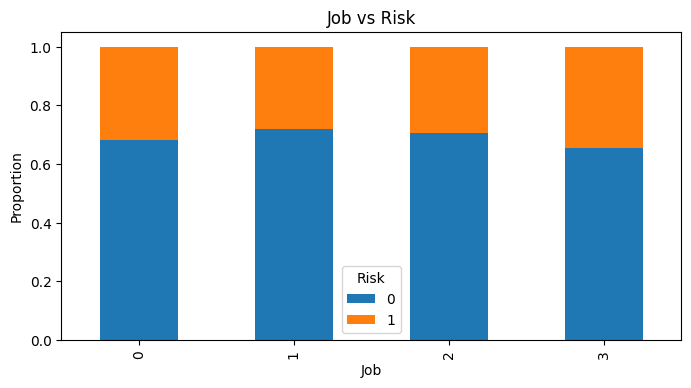


===== Housing vs Risk (row percentage) =====
Risk            0         1
Housing                    
free     0.592593  0.407407
own      0.739130  0.260870
rent     0.608939  0.391061


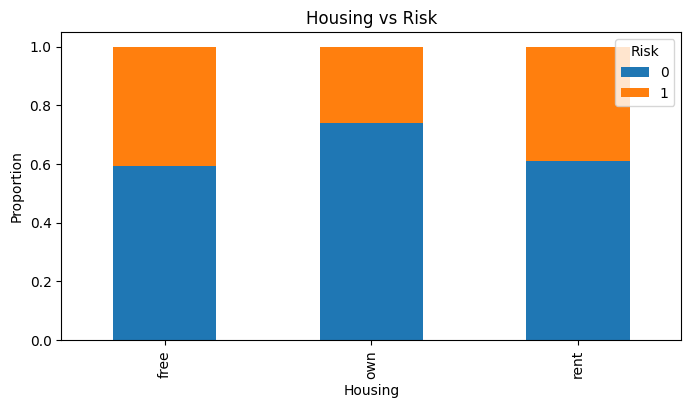


===== Saving accounts vs Risk (row percentage) =====
Risk                    0         1
Saving accounts                    
little           0.640133  0.359867
moderate         0.669903  0.330097
quite rich       0.825397  0.174603
rich             0.875000  0.125000
unknown          0.825137  0.174863


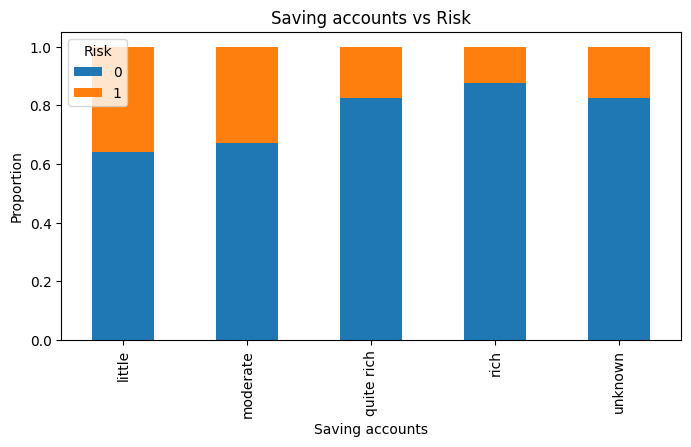


===== Checking account vs Risk (row percentage) =====
Risk                     0         1
Checking account                    
little            0.507299  0.492701
moderate          0.609665  0.390335
rich              0.777778  0.222222
unknown           0.883249  0.116751


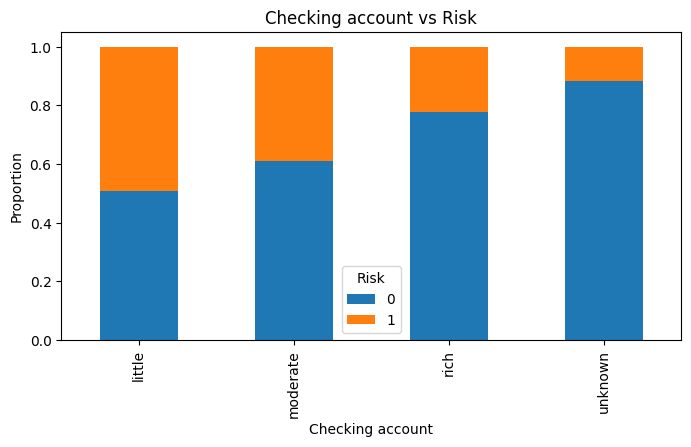


===== Purpose vs Risk (row percentage) =====
Risk                        0         1
Purpose                                
business             0.649485  0.350515
car                  0.685460  0.314540
domestic appliances  0.666667  0.333333
education            0.610169  0.389831
furniture/equipment  0.679558  0.320442
radio/TV             0.778571  0.221429
repairs              0.636364  0.363636
vacation/others      0.583333  0.416667


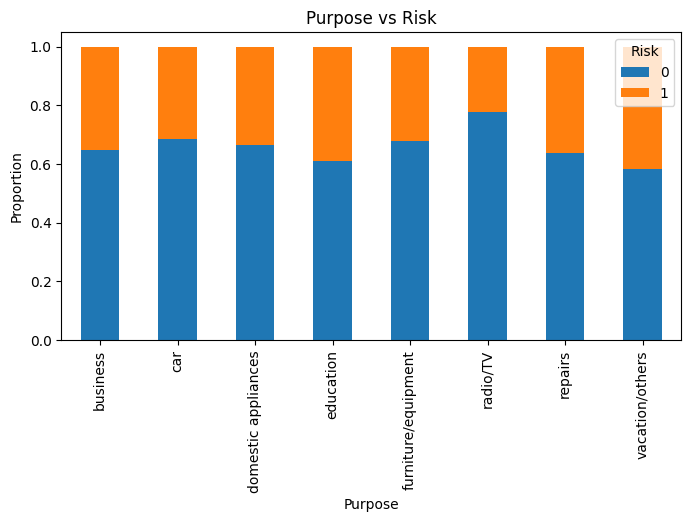

In [14]:
categorical_cols = ["Sex", "Job", "Housing", "Saving accounts", "Checking account", "Purpose"]

for col in categorical_cols:
    ct = pd.crosstab(df[col], df["Risk"], normalize="index")
    print(f"\n===== {col} vs Risk (row percentage) =====")
    print(ct)

    ct.plot(kind="bar", stacked=True, figsize=(8,4))
    plt.title(f"{col} vs Risk")
    plt.ylabel("Proportion")
    plt.show()

In [15]:
for col in categorical_cols:
    table = pd.crosstab(df[col], df["Risk"])
    chi2, p, dof, expected = chi2_contingency(table)

    print(f"\n[Chi-square test] {col} vs Risk")
    print("Chi2 =", chi2)
    print("p-value =", p)
    print("dof =", dof)


[Chi-square test] Sex vs Risk
Chi2 = 5.348516218081436
p-value = 0.020739913068713305
dof = 1

[Chi-square test] Job vs Risk
Chi2 = 1.8851560280131707
p-value = 0.5965815918843433
dof = 3

[Chi-square test] Housing vs Risk
Chi2 = 18.199841582563625
p-value = 0.00011167465374597664
dof = 2

[Chi-square test] Saving accounts vs Risk
Chi2 = 36.098928192418704
p-value = 2.761214238568249e-07
dof = 4

[Chi-square test] Checking account vs Risk
Chi2 = 123.72094351626559
p-value = 1.2189020722893845e-26
dof = 3

[Chi-square test] Purpose vs Risk
Chi2 = 13.642086296939734
p-value = 0.05792591119293633
dof = 7


In [16]:
for col in numeric_cols:
    group_good = df[df["Risk"] == 0][col]
    group_bad = df[df["Risk"] == 1][col]

    t_stat, p_val = ttest_ind(group_good, group_bad, equal_var=False)

    print(f"\n[T-test] {col} by Risk")
    print("mean_good =", group_good.mean())
    print("mean_bad  =", group_bad.mean())
    print("t-statistic =", t_stat)
    print("p-value =", p_val)


[T-test] Age by Risk
mean_good = 36.22428571428571
mean_bad  = 33.96333333333333
t-statistic = 2.9071521165499394
p-value = 0.0037884908809601527

[T-test] Credit amount by Risk
mean_good = 2985.457142857143
mean_bad  = 3938.1266666666666
t-statistic = -4.264219416732966
p-value = 2.477713335048265e-05

[T-test] Duration by Risk
mean_good = 19.207142857142856
mean_bad  = 24.86
t-statistic = -6.469554346236489
p-value = 2.4040808598580764e-10


In [17]:
anova_col = "Purpose"
target_numeric = "Credit amount"

groups = []
for g in df[anova_col].dropna().unique():
    groups.append(df[df[anova_col] == g][target_numeric])

f_stat, p_val = f_oneway(*groups)

print(f"\n[ANOVA] {target_numeric} ~ {anova_col}")
print("F-statistic =", f_stat)
print("p-value =", p_val)


[ANOVA] Credit amount ~ Purpose
F-statistic = 13.341421711796334
p-value = 1.585947764999813e-16


In [18]:
df["Age_group"] = pd.cut(
    df["Age"],
    bins=[18, 30, 45, 60, 100],
    labels=["18-30", "31-45", "46-60", "60+"]
)

df["Credit_per_month"] = df["Credit amount"] / df["Duration"]
df["Log_Credit_amount"] = np.log1p(df["Credit amount"])

print(df[["Age", "Age_group", "Credit amount", "Duration", "Credit_per_month", "Log_Credit_amount"]].head())

   Age Age_group  Credit amount  Duration  Credit_per_month  Log_Credit_amount
0   67       60+           1169         6        194.833333           7.064759
1   22     18-30           5951        48        123.979167           8.691483
2   49     46-60           2096        12        174.666667           7.648263
3   45     31-45           7882        42        187.666667           8.972464
4   53     46-60           4870        24        202.916667           8.491055


In [19]:
features = [
    "Age",
    "Sex",
    "Job",
    "Housing",
    "Saving accounts",
    "Checking account",
    "Credit amount",
    "Duration",
    "Purpose",
    "Age_group",
    "Credit_per_month",
    "Log_Credit_amount"
]

X = df[features]
y = df["Risk"]



In [20]:
numeric_features = ["Age", "Credit amount", "Duration", "Credit_per_month", "Log_Credit_amount"]
categorical_features = ["Sex", "Job", "Housing", "Saving accounts", "Checking account", "Purpose", "Age_group"]



In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape, X_test.shape)

(800, 12) (200, 12)


In [22]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [23]:
logit_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000))
])

logit_model.fit(X_train, y_train)

y_pred_logit = logit_model.predict(X_test)
y_prob_logit = logit_model.predict_proba(X_test)[:, 1]

In [24]:
print("=== Logistic Regression ===")
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_logit))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_logit))

auc_logit = roc_auc_score(y_test, y_prob_logit)
print("\nROC-AUC:", auc_logit)

=== Logistic Regression ===
Confusion Matrix:
[[128  12]
 [ 38  22]]

Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.91      0.84       140
           1       0.65      0.37      0.47        60

    accuracy                           0.75       200
   macro avg       0.71      0.64      0.65       200
weighted avg       0.73      0.75      0.73       200


ROC-AUC: 0.7794047619047619


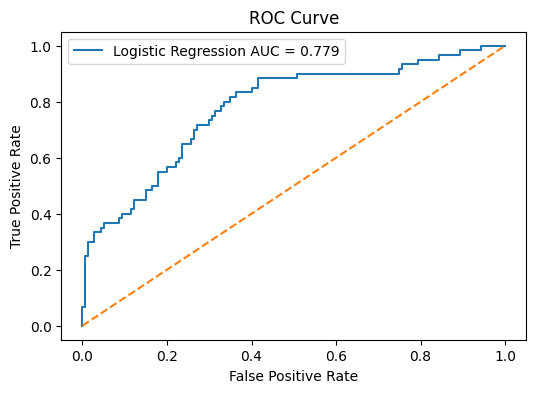

In [25]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob_logit)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"Logistic Regression AUC = {auc_logit:.3f}")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [26]:
rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=200,
        max_depth=5,
        random_state=42
    ))
])

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

In [27]:
print("=== Random Forest ===")
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

auc_rf = roc_auc_score(y_test, y_prob_rf)
print("\nROC-AUC:", auc_rf)

=== Random Forest ===
Confusion Matrix:
[[138   2]
 [ 46  14]]

Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.99      0.85       140
           1       0.88      0.23      0.37        60

    accuracy                           0.76       200
   macro avg       0.81      0.61      0.61       200
weighted avg       0.79      0.76      0.71       200


ROC-AUC: 0.7922619047619047


In [28]:
print("Logistic Regression AUC:", auc_logit)
print("Random Forest AUC:", auc_rf)

Logistic Regression AUC: 0.7794047619047619
Random Forest AUC: 0.7922619047619047


In [29]:
ohe = logit_model.named_steps["preprocessor"].named_transformers_["cat"].named_steps["onehot"]
cat_feature_names = ohe.get_feature_names_out(categorical_features)

all_feature_names = numeric_features + list(cat_feature_names)

coef = logit_model.named_steps["classifier"].coef_[0]

coef_df = pd.DataFrame({
    "Feature": all_feature_names,
    "Coefficient": coef
}).sort_values(by="Coefficient", ascending=False)

print(coef_df.head(15))
print(coef_df.tail(15))

                      Feature  Coefficient
19    Checking account_little     0.657028
26          Purpose_education     0.648217
2                    Duration     0.573140
14     Saving accounts_little     0.521118
15   Saving accounts_moderate     0.468891
29            Purpose_repairs     0.381781
20  Checking account_moderate     0.320603
1               Credit amount     0.319667
13               Housing_rent     0.253627
5                  Sex_female     0.189254
34              Age_group_60+     0.162079
3            Credit_per_month     0.069205
10                      Job_3     0.003841
7                       Job_0     0.000779
33            Age_group_46-60    -0.004067
                        Feature  Coefficient
27  Purpose_furniture/equipment    -0.017644
21        Checking account_rich    -0.022793
11                 Housing_free    -0.042566
31              Age_group_18-30    -0.071608
0                           Age    -0.089329
32              Age_group_31-45    -0.0975

                      Feature  Importance
22   Checking account_unknown    0.146031
3            Credit_per_month    0.107680
2                    Duration    0.106639
1               Credit amount    0.099547
4           Log_Credit_amount    0.088987
19    Checking account_little    0.073351
0                         Age    0.053047
14     Saving accounts_little    0.037327
20  Checking account_moderate    0.030743
18    Saving accounts_unknown    0.029402
12                Housing_own    0.019937
28           Purpose_radio/TV    0.017420
6                    Sex_male    0.014993
26          Purpose_education    0.014749
5                  Sex_female    0.013359
13               Housing_rent    0.012905
32            Age_group_31-45    0.012269
9                       Job_2    0.009676
10                      Job_3    0.009530
31            Age_group_18-30    0.009330


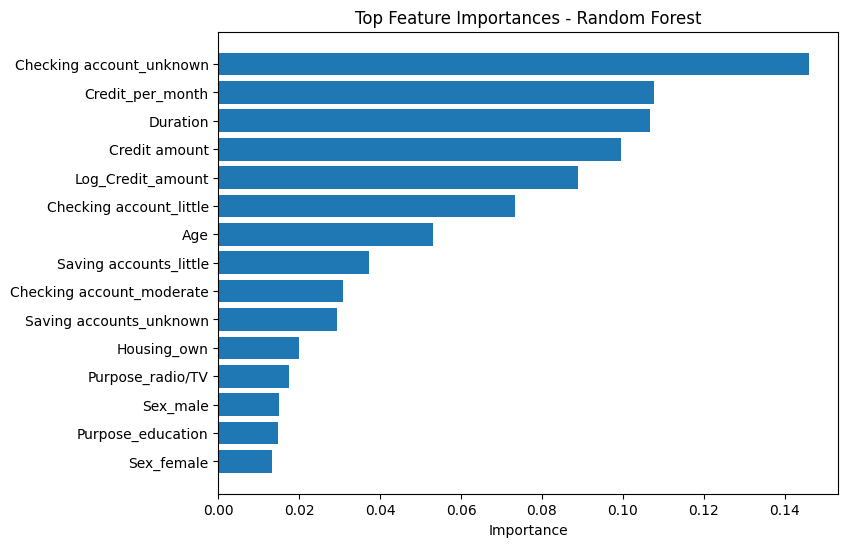

In [30]:
rf_clf = rf_model.named_steps["classifier"]
importances = rf_clf.feature_importances_

importance_df = pd.DataFrame({
    "Feature": all_feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

print(importance_df.head(20))

plt.figure(figsize=(8,6))
top_n = 15
plt.barh(
    importance_df["Feature"].head(top_n)[::-1],
    importance_df["Importance"].head(top_n)[::-1]
)
plt.title("Top Feature Importances - Random Forest")
plt.xlabel("Importance")
plt.show()

Business Interpretation:
1. Variables such as Credit amount, Duration, and Checking account are likely to be important drivers of credit risk.
2. Customers with longer loan duration or weaker account status may have higher default risk.
3. Logistic regression provides interpretable coefficients and can support scorecard-like decision making.
4. Random forest can be used as a benchmark model for predictive performance comparison.

Project Summary:
- Cleaned missing values in account-related variables.
- Performed exploratory analysis on customer demographics and financial characteristics.
- Used chi-square tests for categorical variables and t-tests for numerical variables against Risk.
- Built Logistic Regression and Random Forest models to predict bad credit risk.
- Evaluated models using confusion matrix, classification report, and ROC-AUC.
- Identified important risk drivers for business interpretation.
